# Emirates Auctions Data Analysis — Python Project

## Project Overview
This notebook explores auction performance for **Emirates Auctions 2025** using Python.  
The analysis focuses on understanding auction behavior, participation, and pricing performance  
through both raw variables and calculated analytical indicators.

---

## Dataset Context
The dataset `Emirates_Auctions_Analytical_Enhanced_Final_CLEAN.csv`  
contains details of commercial and charity auctions, including prices, bids, views, and categorical attributes.

> **Note:** The dataset is *synthetically generated* to simulate the structure and behavior of real Emirates Auctions data.  
> It mirrors realistic auction patterns, value distributions, and category relationships typical of the Dubai auction market.

---
> All financial figures are expressed in **UAE Dirhams (AED)**.

## Core Variables

### Financial
- `start_price` → Initial auction price.  
- `final_price` → Final selling price (main outcome).  
- `target_price` → Expected or reference price.  
- `revenue` / `charity_revenue` → Total auction value (depending on auction type).

### Engagement
- `bids_count` → Total number of bids placed.  
- `num_bidders` → Number of unique bidders.  
- `views` → Total views or impressions of the auction.

### Behavioral and Time
- `duration_days` → Duration of each auction in days.  
- `month`, `auction_quarter`, `hour_of_day` → Indicators of timing or seasonality.

---

## Analytical Indicators

- `achievement_ratio` → `final_price / target_price`  
  Measures how close the auction came to or exceeded its target price.  

- `price_uplift` → Relative increase over starting price.  

- `profit_margin_proxy` → Approximation of profit percentage or margin.  

- `popularity_index` → Composite indicator of engagement (views, bids, bidders).  

- `auction_popularity_score` → Weighted score summarizing auction visibility and interaction.  

- `bids_per_bidder` → `bids_count / num_bidders`  
  Reflects bidding intensity per participant.  

- `views_per_bid` → `views / bids_count`  
  Indicates how many views are required to trigger a bid (conversion efficiency).  

---

## Tools and Libraries
- **Python (Anaconda environment)**  
- **pandas** — Data manipulation, cleaning, and statistical summaries.  
- **matplotlib** — Visualization and pattern exploration.  
- **NumPy** — Numerical operations and support for vectorized calculations (used where needed).  

---

## Objective
To identify behavioral and financial patterns that define successful auctions  
and to prepare metrics that can later be visualized and compared in **Power BI** or **R**.


## Data Loading and Preparation

In [1]:
# --- Import required libraries ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# --- Load dataset ---
df = pd.read_csv("Emirates_Auctions_Analytical_Enhanced_Final_CLEAN.csv")

# --- Display basic information ---
print("Rows:", df.shape[0], "| Columns:", df.shape[1])
display(df.head())

Rows: 2592 | Columns: 38


,auction_id,title,category,subcategory,emirate,listing_type,auction_status,start_time,end_time,duration_days,...,month,auction_month_name,auction_quarter,bid_per_user,popularity_index,auction_popularity_score,price_segment,beneficiary,charity_revenue,revenue
0,AUC-1,Vehicles 1759,Vehicles,Car,Umm Al Quwain,Auction,Closed,2025-09-26 08:00:00,2025-09-27 08:00:00,1.000,...,9.0,September,3.0,1.400000,6.05,43.63,High,NaN,0.0,229699.13
1,AUC-2,Vehicles 3332,Vehicles,Car,Ras Al Khaimah,Auction,Closed,2025-10-18 23:00:00,2025-10-19 18:00:00,0.792,...,10.0,October,4.0,1.739130,3.58,42.15,Mid,NaN,0.0,50500.56
2,AUC-3,Vehicles 1587,Vehicles,Car,Sharjah,Auction,Closed,2025-09-10 01:00:00,2025-09-10 11:00:00,0.417,...,9.0,September,3.0,2.285714,20.86,52.52,High,NaN,0.0,258826.95
3,AUC-4,Vehicles 2757,Vehicles,Car,Ajman,BuyNow,Closed,2025-09-29 10:00:00,2025-09-29 23:00:00,0.687,...,9.0,September,3.0,3.400000,26.73,56.04,Mid,NaN,0.0,56776.95
4,AUC-5,Vehicles 1674,Vehicles,Car,Umm Al Quwain,Auction,Closed,2025-09-30 15:00:00,2025-10-01 18:00:00,1.125,...,9.0,September,3.0,1.466667,32.99,59.79,Mid,NaN,0.0,73703.59


# Exploratory Data Analysis (EDA)

This section focuses on exploring the dataset to understand its structure, quality, and main statistical characteristics.  
The goal is to identify key variables, detect missing or inconsistent data, and visualize general patterns before deeper analysis.

## Step 1 – Data Structure and Quality

In [2]:
# --- Show column names and data types ---
df.info();
print("\n" + "-"*40)
# --- Quick summary of column types ---
print("\nNumeric columns:", df.select_dtypes(include=np.number).shape[1])
print("Categorical columns:", df.select_dtypes(exclude=np.number).shape[1])

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2592 entries, 0 to 2591
Data columns (total 38 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   auction_id                2592 non-null   object 
 1   title                     2592 non-null   object 
 2   category                  2592 non-null   object 
 3   subcategory               2592 non-null   object 
 4   emirate                   2592 non-null   object 
 5   listing_type              2592 non-null   object 
 6   auction_status            2592 non-null   object 
 7   start_time                2592 non-null   object 
 8   end_time                  2592 non-null   object 
 9   duration_days             2592 non-null   float64
 10  as_of_date                2592 non-null   object 
 11  start_price               2592 non-null   float64
 12  final_price               2592 non-null   float64
 13  target_price              2592 non-null   float64
 14  achievem

## Step 1.1 – Categorical Columns Overview

In [3]:
# --- Quick look at unique values in categorical columns ---
for col in df.select_dtypes(exclude=np.number).columns:
    print(f"{col}: {df[col].nunique()} unique values")

auction_id: 2592 unique values
title: 2510 unique values
category: 6 unique values
subcategory: 11 unique values
emirate: 10 unique values
listing_type: 3 unique values
auction_status: 1 unique values
start_time: 1258 unique values
end_time: 1252 unique values
as_of_date: 1 unique values
vehicle_type: 3 unique values
charity_flag: 2 unique values
day_of_week: 7 unique values
auction_month_name: 12 unique values
price_segment: 3 unique values
beneficiary: 8 unique values


## Step 2 – Missing Values and Zero Values 

In [4]:
# --- Missing values ---
print("\nMissing values:")
print(df.isnull().sum().sort_values(ascending=False).head(10))

# --- Zero or invalid values ---
print("\nZero or invalid values:")
key_cols = ['start_price', 'final_price', 'target_price', 'bids_count', 'num_bidders', 'views']
for col in key_cols:
    zero_count = (df[col] == 0).sum()
    if zero_count > 0:
        print(f"{col}: {zero_count} zeros found")
    else:
        print(f"{col}: No zeros found")



Missing values:
make              2592
beneficiary       2532
vehicle_type      1532
category             0
auction_id           0
title                0
listing_type         0
emirate              0
subcategory          0
auction_status       0
dtype: int64

Zero or invalid values:
start_price: No zeros found
final_price: No zeros found
target_price: No zeros found
bids_count: No zeros found
num_bidders: No zeros found
views: No zeros found


In [5]:

# --- Check zero or negative values in key numeric columns ---
key_cols = ['start_price', 'final_price', 'target_price', 'bids_count', 'num_bidders', 'views']
for col in key_cols:
    zero_count = (df[col] == 0).sum()
    if zero_count > 0:
        print(f"{col}: {zero_count} zeros found")
    else:
        print(f"{col}: No zeros found")


start_price: No zeros found
final_price: No zeros found
target_price: No zeros found
bids_count: No zeros found
num_bidders: No zeros found
views: No zeros found


## Step 3 – Descriptive Statistics

In [6]:
# --- Generate descriptive statistics for numeric columns ---
df.describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
duration_days,2592.0,1.59,0.83,0.17,0.88,1.58,2.29,3.39
start_price,2592.0,599400.84,3716267.21,174.00,18784.50,59896.50,163832.59,68544000.00
final_price,2592.0,923996.10,5333443.79,225.75,30248.48,97463.50,264575.86,97920000.00
target_price,2592.0,700503.72,3894108.73,208.16,21141.09,72550.23,197904.35,74591260.60
achievement_ratio,2592.0,1.38,0.29,0.75,1.13,1.37,1.61,2.08
bids_count,2592.0,50.09,106.33,1.00,19.75,38.00,61.00,1968.00
num_bidders,2592.0,21.90,52.60,1.00,9.00,18.00,27.00,984.00
views,2592.0,923.19,2286.54,10.00,312.75,633.00,1048.50,46455.00
price_uplift,2592.0,0.63,0.33,0.05,0.36,0.62,0.92,1.20
profit_margin_proxy,2592.0,324595.27,1631800.83,32.96,9235.72,32423.90,111186.32,29376000.00


In [7]:
# --- Basic logical validation checks ---

# Price-related sanity checks
print((df['final_price'] < df['start_price']).sum(), "rows where final < start")
print((df['target_price'] <= 0).sum(), "rows with non-positive target price")

# Duration-related sanity check
print((df['duration_days'] <= 0).sum(), "rows with non-positive duration")

# Engagement-related sanity checks
print((df['bids_count'] < 0).sum(), "rows with negative bids count")
print((df['num_bidders'] < 0).sum(), "rows with negative bidder count")

# Analytical indicator sanity check
print((df['achievement_ratio'] < 0).sum(), "rows with negative achievement ratio")


0 rows where final < start
0 rows with non-positive target price
0 rows with non-positive duration
0 rows with negative bids count
0 rows with negative bidder count
0 rows with negative achievement ratio


## Step 4 – Visual Exploration

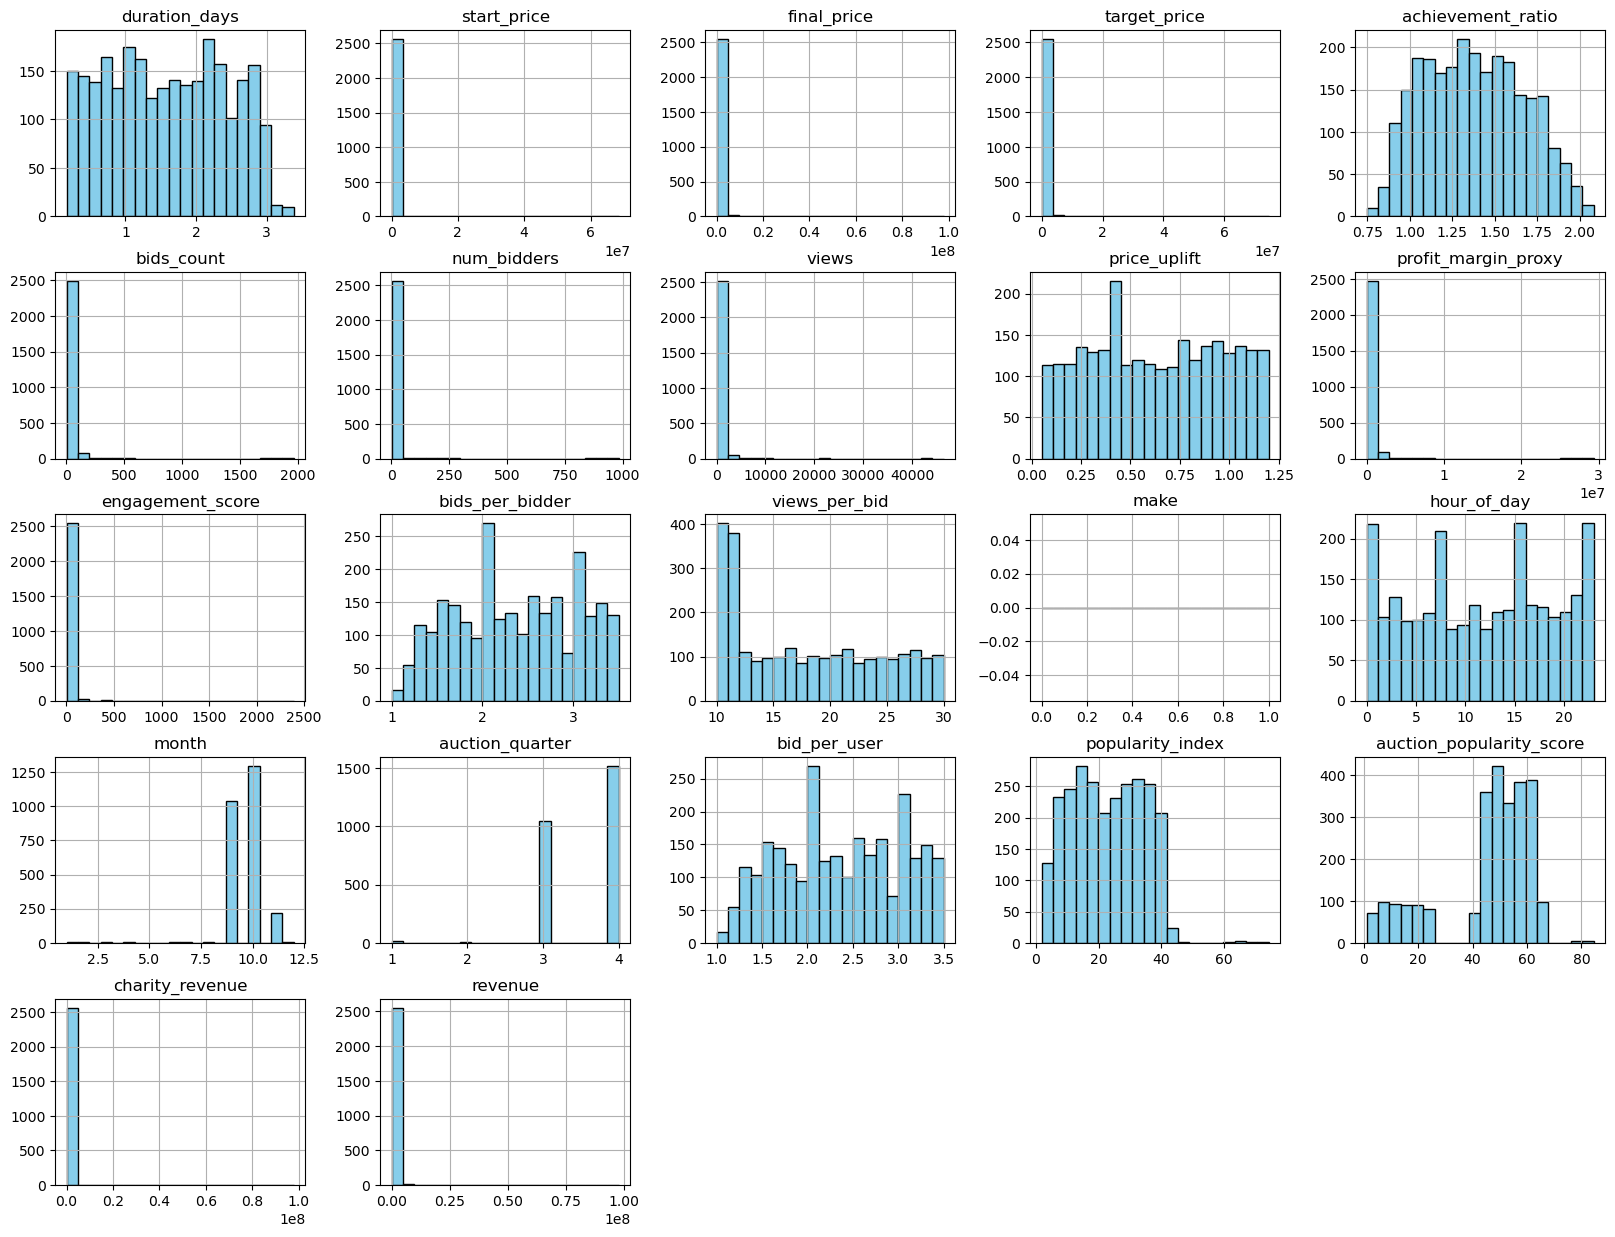

In [8]:
# --- Visualize the distribution of all numeric variables ---
df.hist(figsize=(20,15), bins=20, color='skyblue', edgecolor='black');

## Data Overview and Initial Exploration

A general distribution analysis using `df.hist()` was conducted to understand the overall behavior of numeric variables **before** detailed exploration.  
The dataset appears **clean and well-structured**, with logical ranges and minimal missing values.

---

### Main Findings

#### Financial Variables  
**Columns:** `start_price`, `target_price`, `final_price`, `revenue`  
- Distributions are strongly right-skewed.  
- This indicates that most auctions cluster around low values, with a long tail of high-value outliers — a typical pattern for auction datasets.

#### Engagement Variables  
**Columns:** `bids_count`, `num_bidders`, `views`  
- Follow a similar right-skewed pattern.  
- A small number of highly competitive auctions drive the majority of bidding activity.

#### Behavioral and Time-Related Variables  
**Columns:** `duration_days`, `month`, `auction_quarter`, `hour_of_day`  
- Auction durations are generally short (**1–3 days**).  
- Activity appears concentrated in specific months and hours, suggesting temporal patterns worth deeper analysis.

#### Analytical Indicators  
**Columns:** `achievement_ratio`, `price_uplift`, `popularity_index`, `auction_popularity_score`  
- Show more balanced distributions.  
- Indicate stable auction performance and consistent pricing behavior.

---

### Next Steps

Subsequent analysis will focus on how the key variables —  
`final_price`, `bids_count`, `views`, `num_bidders`, `duration_days`, and `achievement_ratio` —  
interact to define **auction performance**, **participation behavior**, and **success patterns across categories**.

# Transition to Detailed Exploration

With the dataset validated for quality and its distributions understood,  
the next phase explores **key performance variables** that influence auction outcomes.  
All financial metrics are expressed in **UAE Dirhams (AED)**.  
The detailed exploration begins with `final_price`, the main financial output of each auction.

# Detailed Exploration of Key Variables

## Step 5.1 – Final Price Distribution and Behavior (AED)

This step analyzes the distribution and statistical behavior of `final_price`,  
representing the final auction selling value in **UAE Dirhams (AED)**.

**Goals**
- Understand the distribution shape and skewness.  
- Review key descriptive metrics: mean, median, 90th percentile, and maximum (100th percentile).  
- Determine whether auction prices typically fall within **thousands, millions, or billions AED**.  
- Use the **90th percentile** to capture the *upper realistic range* of successful auction prices,  
  while the **maximum (100th percentile)** identifies extreme or outlier values.

In [9]:
# --- Helper functions for numeric analysis and visualization ---

# Histogram plot for numeric series
def plot_hist(series, title, xlabel, bins=30, figsize=(8,5)):
    plt.figure(figsize=figsize)
    plt.hist(series, bins=bins, color='skyblue', edgecolor='black')
    plt.title(title, fontsize=14)
    plt.xlabel(xlabel)
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()

# Summary statistics for numeric series (no rounding, fixed format)
def summarize(series, p_list=(0.9, 1.0)):
    print("Minimum:", f"{series.min():,.0f}")
    print("Maximum:", f"{series.max():,.0f}")
    print("Mean:", f"{series.mean():,.0f}")
    print("Median:", f"{series.median():,.0f}")
    for p in p_list:
        val = series.quantile(p)
        print(f"P{int(p*100)}:", f"{val:,.0f}")

# Summary for fractional/ratio-based values
def summarize_fraction(series, p_list=(0.9, 1.0)):
    print("Minimum:", f"{series.min():,.2f}")
    print("Maximum:", f"{series.max():,.2f}")
    print("Mean:", f"{series.mean():,.2f}")
    print("Median:", f"{series.median():,.2f}")
    for p in p_list:
        val = series.quantile(p)
        print(f"P{int(p*100)}:", f"{val:,.2f}")

# Scatter plot for numeric relationships
def plot_scatter(x, y, title, xlabel, ylabel, alpha=0.5, figsize=(7,5)):
    plt.figure(figsize=figsize)
    plt.scatter(x, y, alpha=alpha, color='orange', edgecolors='black', linewidths=0.3)
    plt.title(title, fontsize=14)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.tight_layout()
    plt.show()

    # --- Helper function for horizontal bar charts ---
def plot_barh(data, title, xlabel, ylabel, color='skyblue', n=24):
    ax = data.head(n).plot(kind='barh', color=color, edgecolor='black', figsize=(8,4))
    plt.title(title, fontsize=14)
    plt.xlabel(xlabel, fontsize=12)
    plt.ylabel(ylabel, fontsize=12)
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()

Minimum: 226
Maximum: 97,920,000
Mean: 923,996
Median: 97,463
P90: 2,288,246
P100: 97,920,000


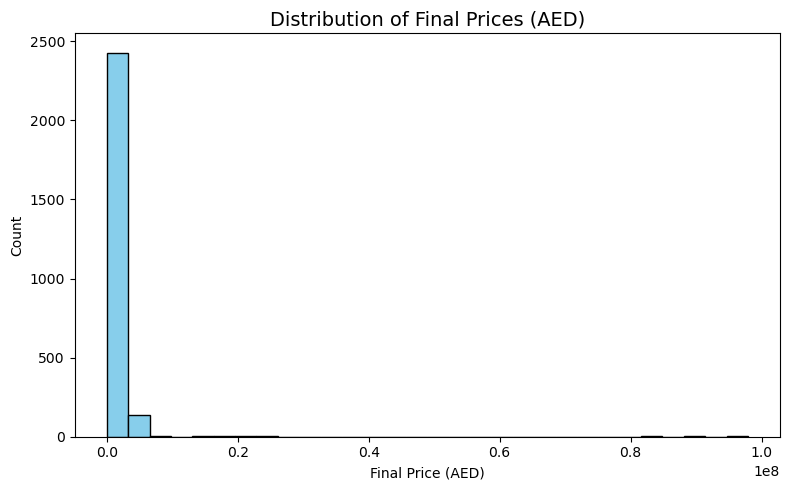

In [10]:
# --- Step 5.1 – Final Price Distribution and Behavior (AED) ---
summarize(df['final_price'])
plot_hist(df['final_price'], "Distribution of Final Prices (AED)", "Final Price (AED)", bins=30)

### Interpretation – Final Price Distribution
The `final_price` variable is highly right-skewed.  
Most auctions close below 100K AED, while a few rare cases reach up to 98M AED,  
confirming the presence of both regular and luxury auctions in the dataset.


## Step 5.2 – Bidding and Engagement Activity

This section explores how engagement metrics such as `bids_count`, `num_bidders`,  
and `views` relate to the final auction price (`final_price`).

**Goals**
- Assess whether higher participation leads to higher final prices.  
- Identify which engagement factor (bids, bidders, or views) shows the strongest relationship.  
- Visually inspect outliers and correlation patterns.


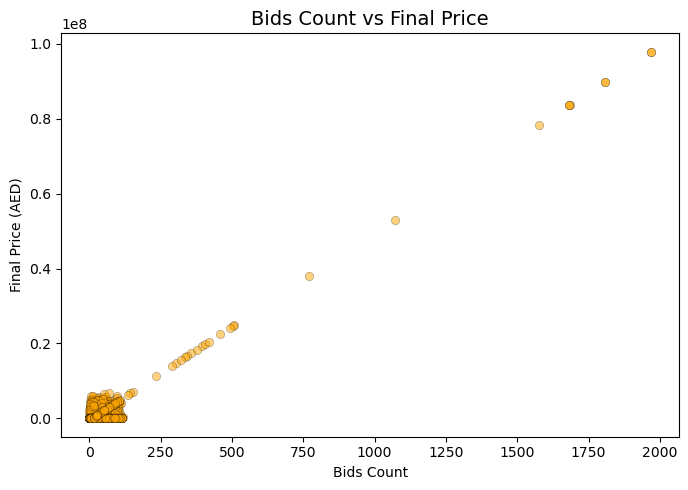

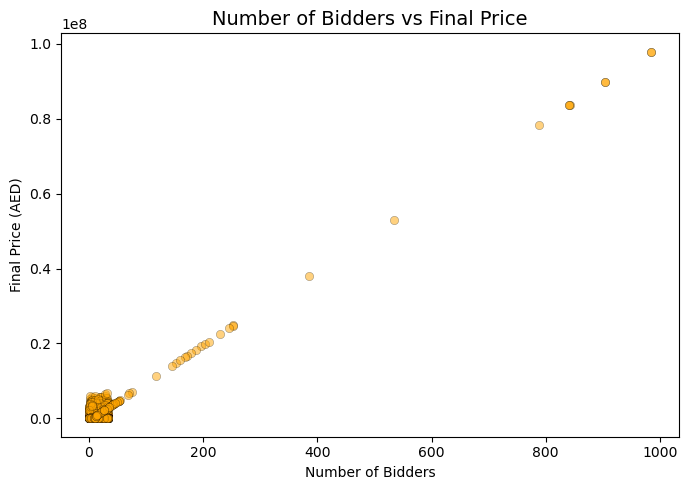

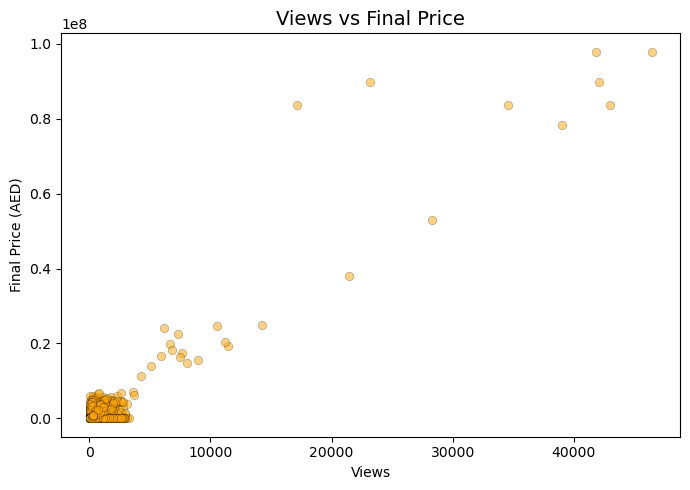

In [11]:
# --- Step 5.2 – Bidding and Engagement Activity ---
# Bids Count vs Final Price
plot_scatter(df['bids_count'], df['final_price'],
             "Bids Count vs Final Price", "Bids Count", "Final Price (AED)")

# Number of Bidders vs Final Price
plot_scatter(df['num_bidders'], df['final_price'],
             "Number of Bidders vs Final Price", "Number of Bidders", "Final Price (AED)")

# Views vs Final Price
plot_scatter(df['views'], df['final_price'],
             "Views vs Final Price", "Views", "Final Price (AED)")

Correlation Matrix:
             final_price  bids_count  num_bidders     views
final_price     1.000000    0.949308     0.964664  0.920188
bids_count      0.949308    1.000000     0.991549  0.958979
num_bidders     0.964664    0.991549     1.000000  0.954358
views           0.920188    0.958979     0.954358  1.000000


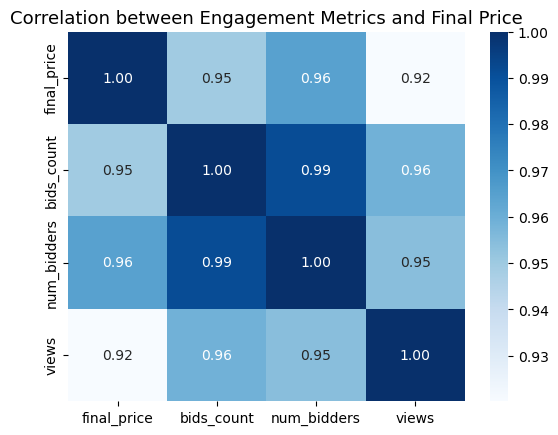

In [12]:
# 2️ Correlation analysis
corr_vars = ['final_price', 'bids_count', 'num_bidders', 'views']
correlation_matrix = df[corr_vars].corr(method='pearson')

print("Correlation Matrix:")
print(correlation_matrix)

sns.heatmap(correlation_matrix, annot=True, cmap='Blues', fmt=".2f")
plt.title("Correlation between Engagement Metrics and Final Price", fontsize=13)
plt.show()

### Interpretation
All engagement metrics show a very strong positive correlation (≥ 0.9)  
with `final_price`, confirming that higher bidding activity and participation  
are directly linked to increased auction value.

# Step 5.3 – Achievement Ratio Analysis  

This step evaluates how closely each auction’s **final price** matched or exceeded  
its **target price** using the analytical column `achievement_ratio`.

**Objective**
- Understand whether auctions typically meet, fall short of, or exceed target prices.  
- Identify the range and distribution of pricing performance.  
- Support later comparisons between categories and auction types.

Minimum: 0.75
Maximum: 2.08
Mean: 1.38
Median: 1.37
P90: 1.79
P100: 2.08


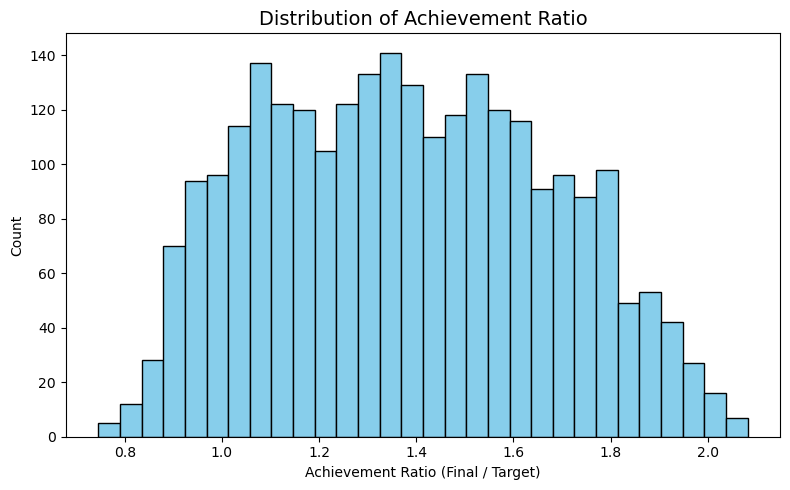

In [13]:
# --- Step 5.3 – Achievement Ratio Analysis ---
# Purpose: Measure how final prices compare to target prices.

summarize_fraction(df['achievement_ratio'])
plot_hist(df['achievement_ratio'],"Distribution of Achievement Ratio","Achievement Ratio (Final / Target)",bins=30)

### Interpretation  
The `achievement_ratio` values range between **0.75** and **2.08**,  
with an average of **1.38** and median of **1.37**.  
This indicates that most auctions **meet or exceed** their target prices,  
typically closing around **35–40% above expectations**.  
Only a few auctions fall below 1.0, while ratios above **1.8–2.0**  
represent exceptional cases of highly competitive bidding.

# Step 5.4 – Duration and Timing Analysis  

This step explores how the **timing and duration** of auctions  
relate to overall participation and final price behavior.  
The focus is on variables:  
- `duration_days` → total length of the auction  
- `month`, `auction_quarter`, `hour_of_day` → time-based indicators for seasonality and activity patterns.

Minimum: 0
Maximum: 3
Mean: 2
Median: 2
P90: 3
P100: 3


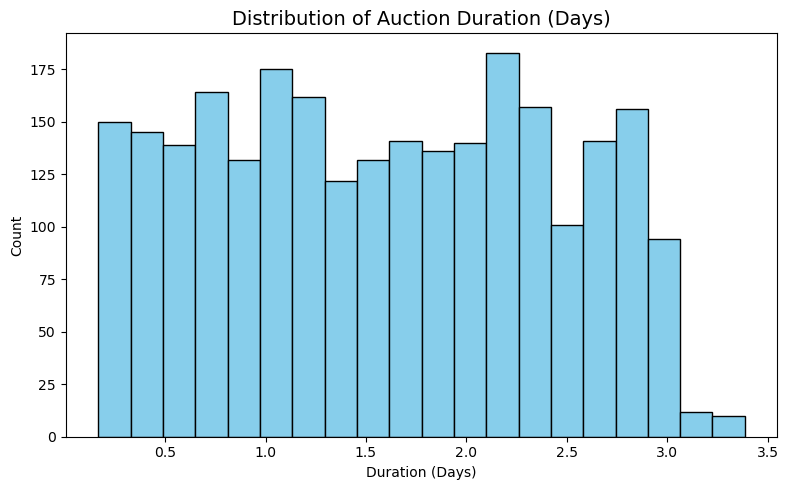

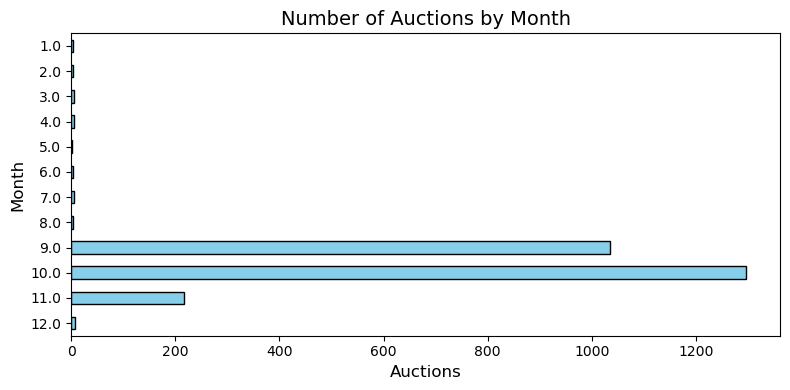

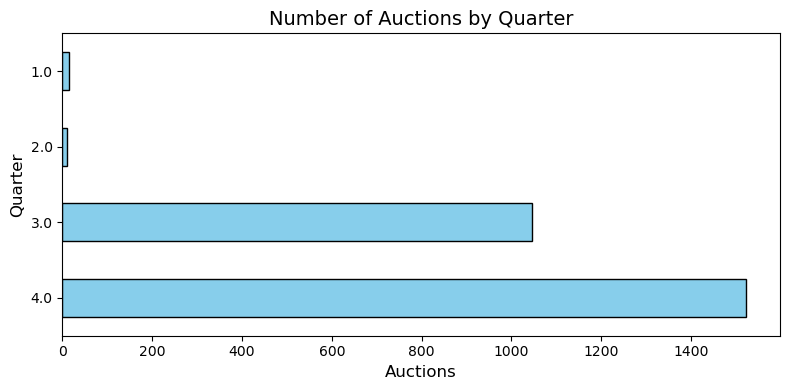

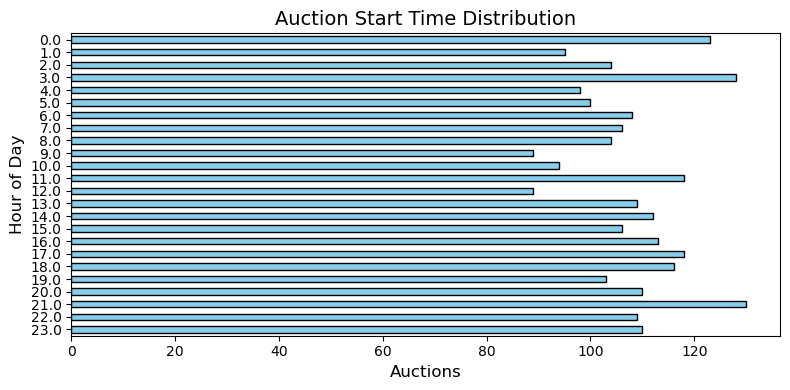

In [14]:
# --- Step 5.4 – Duration and Timing Analysis ---
# Purpose: Examine how auction timing and duration affect performance.

# 1️ Auction Duration Distribution
summarize(df['duration_days'])
plot_hist(df['duration_days'],
          "Distribution of Auction Duration (Days)",
          "Duration (Days)",
          bins=20)

# 2️ Monthly activity pattern
month_counts = df['month'].value_counts().sort_index()
plot_barh(month_counts, "Number of Auctions by Month", "Auctions", "Month")

# 3️ Quarterly pattern
quarter_counts = df['auction_quarter'].value_counts().sort_index()
plot_barh(quarter_counts, "Number of Auctions by Quarter", "Auctions", "Quarter")

# 4️ Hour of the Day
hour_counts = df['hour_of_day'].value_counts().sort_index()
plot_barh(hour_counts, "Auction Start Time Distribution", "Auctions", "Hour of Day")

### Interpretation  
Most auctions last **1–3 days**, confirming short bidding windows typical of online auctions.  
Monthly and quarterly distributions show **seasonal spikes**, likely aligned with campaign or event schedules.  
Activity by hour reveals **clear engagement peaks** during mid-day and early-evening hours,  
indicating optimal timing for visibility and participation.

# Step 6 – Category-Level Analysis  
> All financial figures are expressed in **UAE Dirhams (AED)**.


Now that overall patterns and behaviors are understood,  
this step shifts the focus toward **category-level performance**.  
The goal is to identify which auction categories and listing types  
drive the highest participation and final prices.

**Focus Variables**  
- `category` and `subcategory`  
- `listing_type` (e.g., commercial vs charity)  
- `final_price`, `achievement_ratio`, `bids_count`

**Objectives**  
- Compare average and total auction values across categories.  
- Evaluate engagement and pricing efficiency (`achievement_ratio`) per category.  
- Identify high-performing or underperforming auction segments.

## Step 6.1 – Category Volume and Value Overview  

This step analyzes auction performance at the **category level**,  
highlighting which main auction groups drive the highest participation  
and contribute most to total auction value across Emirates Auctions.


Number of Auctions per Category:
category
Vehicles               1060
General Items           960
Plates                  344
Jewellery & Watches      96
Property                 72
Charity                  60
Name: count, dtype: int64
--------------------------------------------------


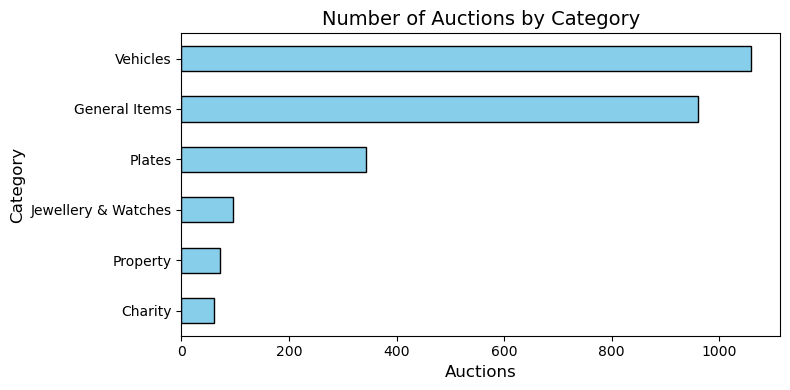

Total Final Price (AED) per Category:
category
Charity                1,186,995,999
Plates                   823,716,838
Vehicles                 180,124,408
Property                 160,855,440
General Items             29,464,875
Jewellery & Watches       13,840,339
Name: final_price, dtype: object
--------------------------------------------------


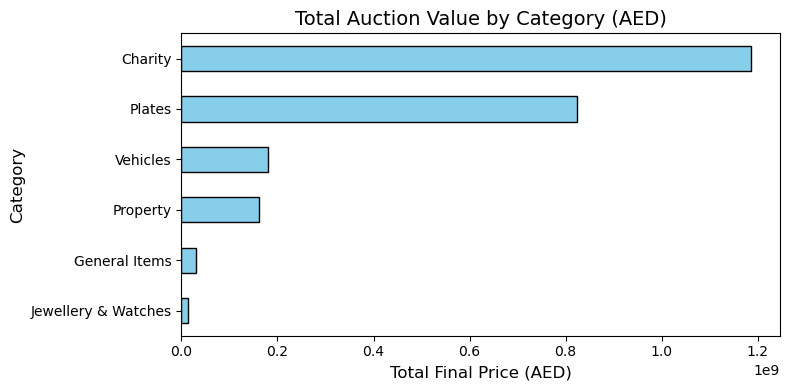

In [15]:
# --- Step 6.1 – Category Volume and Value Overview ---
# Purpose: Compare the number of auctions and total value across categories.

# 1️ Auctions count per category
cat_counts = df['category'].value_counts()

print("Number of Auctions per Category:")
print(cat_counts)
print("-" * 50)
plot_barh(cat_counts,"Number of Auctions by Category", "Auctions", "Category")

# 2️ Total final price per category (AED)
cat_value = (df.groupby('category', dropna=False)['final_price'].sum().sort_values(ascending=False))

print("Total Final Price (AED) per Category:")
print(cat_value.apply(lambda x: f"{x:,.0f}"))
print("-" * 50)
plot_barh(cat_value, "Total Auction Value by Category (AED)", "Total Final Price (AED)", "Category")

## Category-Level Interpretation
- Vehicles and General Items have the highest auction volumes (over 900 each).
- Charity and Plates categories lead in total auction value, exceeding AED 1.18B and 0.82B respectively.
- Most auctions are low-value, but a few premium categories dominate total revenue.

## Step 6.2 – Subcategory-Level Analysis  

This step examines auction performance at the **subcategory level**,  
identifying which specific segments generate the highest auction volume and total value.

Number of Auctions per Subcategory:
subcategory
Car                   1004
General                960
Prestigious Number     344
Jewellery/Watches       96
Charity Event           60
Motorcycle              38
Property                32
Apartment               22
Bus                     18
Office                  14
Villa                    4
Name: count, dtype: int64
--------------------------------------------------


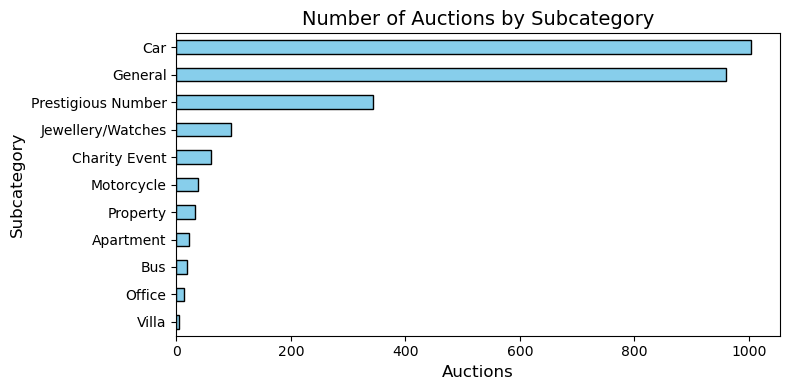

Total Final Price (AED) per Subcategory:
subcategory
Charity Event         1,186,995,999
Prestigious Number      823,716,838
Car                     170,447,973
Property                 82,456,519
Apartment                42,202,057
General                  29,464,875
Office                   28,666,956
Jewellery/Watches        13,840,339
Villa                     7,529,908
Motorcycle                6,499,287
Bus                       3,177,147
Name: final_price, dtype: object
--------------------------------------------------


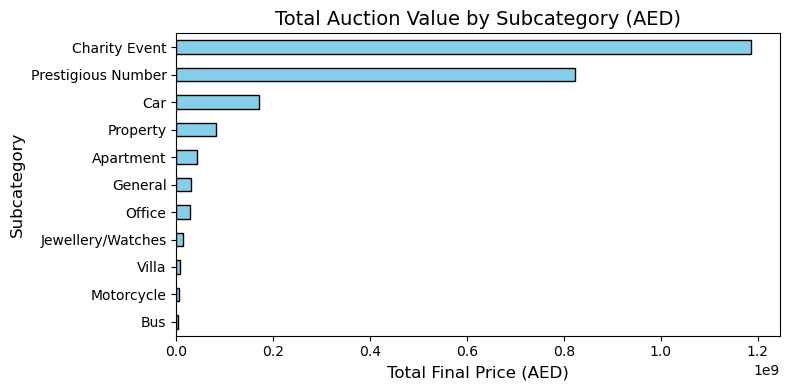

In [16]:
# --- Step 6.2 – Subcategory-Level Analysis ---
# Purpose: Compare the number of auctions and total value across subcategories.

# 1️ Count of auctions per subcategory
subcat_counts = df['subcategory'].value_counts()
print("Number of Auctions per Subcategory:")
print(subcat_counts)
print("-" * 50)
plot_barh(subcat_counts, "Number of Auctions by Subcategory", "Auctions", "Subcategory")

# 2️ Total final price per subcategory (AED)
subcat_value = df.groupby('subcategory', dropna=False)['final_price'].sum().sort_values(ascending=False)
print("Total Final Price (AED) per Subcategory:")
print(subcat_value.apply(lambda x: f"{x:,.0f}"))
print("-" * 50)
plot_barh(subcat_value, "Total Auction Value by Subcategory (AED)", "Total Final Price (AED)", "Subcategory")

## Subcategory-Level Interpretation
- Car and General subcategories record the highest participation, around 1,000 auctions each.
- Charity Event and Prestigious Number generate the majority of total value (over AED 2B combined).
- High-value transactions are concentrated in limited, premium subcategories.

## Step 6.3 – Listing Type Analysis  

This step explores how different **listing types** (e.g., commercial, charity, special)  
contribute to auction volume and total value, helping identify which auction formats  
generate the most engagement and revenue.

Number of Auctions per Listing Type:
listing_type
Auction            2030
BuyNow              502
Charity Auction      60
Name: count, dtype: int64
--------------------------------------------------


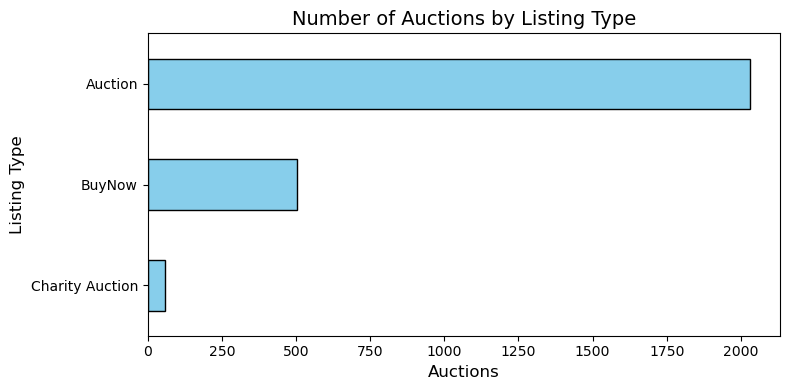

Total Final Price (AED) per Listing Type:
listing_type
Charity Auction    1,186,995,999
Auction              991,984,513
BuyNow               216,017,388
Name: final_price, dtype: object
--------------------------------------------------


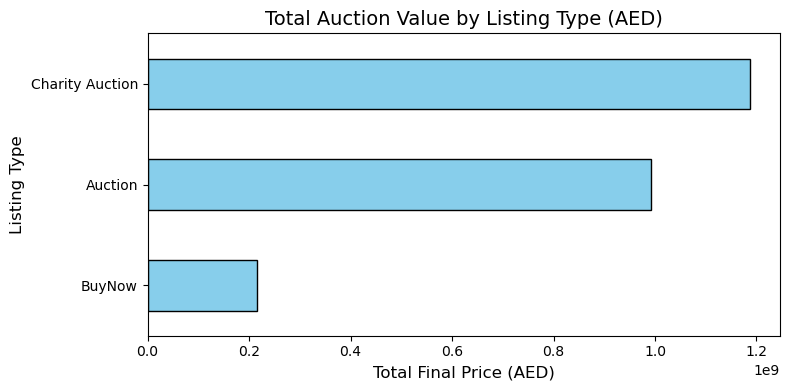

In [17]:
# --- Step 6.3 – Listing Type Analysis ---
# Purpose: Compare the number of auctions and total value across listing types.

# 1️ Count of auctions per listing type
listing_counts = df['listing_type'].value_counts()
print("Number of Auctions per Listing Type:")
print(listing_counts)
print("-" * 50)
plot_barh(listing_counts, "Number of Auctions by Listing Type", "Auctions", "Listing Type")

# 2️ Total final price per listing type (AED)
listing_value = df.groupby('listing_type', dropna=False)['final_price'].sum().sort_values(ascending=False)
print("Total Final Price (AED) per Listing Type:")
print(listing_value.apply(lambda x: f"{x:,.0f}"))
print("-" * 50)
plot_barh(listing_value, "Total Auction Value by Listing Type (AED)", "Total Final Price (AED)", "Listing Type")

## Listing Type Interpretation
- Auction listings represent most activity (≈2,000), reflecting strong competition.
- Charity Auctions, though few (60), produce the highest total value (≈AED 1.18B).
- BuyNow listings show lower participation and financial contribution.

## Step 6.4 – Performance Insights Across Categories  

This section evaluates **efficiency** and **engagement** across different taxonomy levels —  
from main categories down to subcategories and listing types —  
to identify the auction segments that achieve the strongest participation and pricing performance.

**Focus Variables**  
- `category`, `subcategory`, `listing_type`  
- `achievement_ratio` (pricing efficiency)  
- `bids_count` (engagement intensity)

## Step 6.4a – Category Performance Insights  

This step analyzes **average achievement ratios** and **bidding activity** across main categories,  
to identify which auction groups combine strong price performance with high participation.

### Step 6.4a – Category Performance Insights  

This step analyzes **average achievement ratios** and **bidding activity** across **main categories**,  
to identify which groups combine strong price performance with high participation.

Average Achievement Ratio per Category:
category
Jewellery & Watches    1.47
General Items          1.45
Charity                1.36
Vehicles               1.35
Property               1.29
Plates                 1.25
Name: achievement_ratio, dtype: float64
--------------------------------------------------


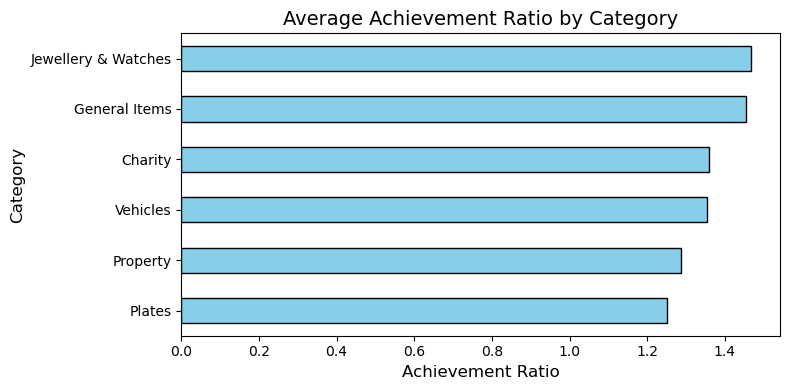

Average Bids per Auction per Category:
category
Charity                405.2
Property                42.3
General Items           42.0
Vehicles                41.7
Plates                  40.9
Jewellery & Watches     40.3
Name: bids_count, dtype: float64
--------------------------------------------------


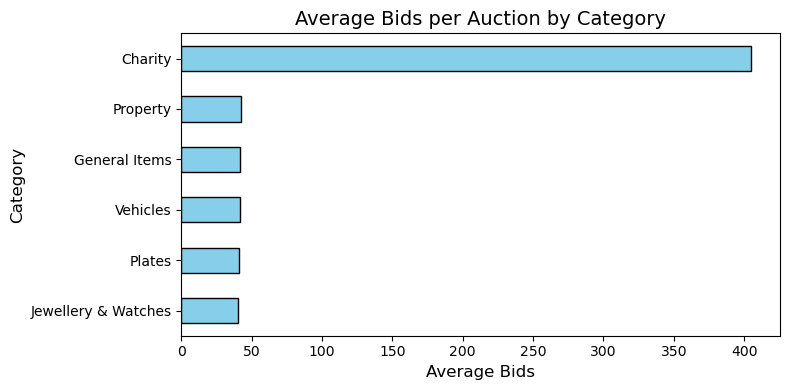

In [18]:
# --- Step 6.4a – Category Performance Insights ---
# Purpose: Compare efficiency and engagement across categories.

# 1️ Average achievement ratio per category
cat_avg_ratio = df.groupby('category')['achievement_ratio'].mean().sort_values(ascending=False)
print("Average Achievement Ratio per Category:")
print(cat_avg_ratio.round(2))
print("-" * 50)
plot_barh(cat_avg_ratio, "Average Achievement Ratio by Category", "Achievement Ratio", "Category")

# 2️ Average bids per auction per category
cat_avg_bids = df.groupby('category')['bids_count'].mean().sort_values(ascending=False)
print("Average Bids per Auction per Category:")
print(cat_avg_bids.round(1))
print("-" * 50)
plot_barh(cat_avg_bids, "Average Bids per Auction by Category", "Average Bids", "Category")

### Interpretation 
Charity auctions show the highest engagement (≈400 bids/auction) and strong achievement ratios,  
while Jewellery & Watches and General Items reach the best price performance relative to targets.  
High-value segments like Property and Plates remain stable but less competitive.

### Step 6.4b – Subcategory Performance Insights  

Analyze **average achievement ratio** and **average bids per auction** across **subcategories**  
to surface premium segments with both strong pricing and high engagement.


Average Achievement Ratio per Subcategory:
subcategory
Jewellery/Watches     1.47
General               1.45
Property              1.37
Office                1.36
Charity Event         1.36
Car                   1.36
Motorcycle            1.34
Bus                   1.29
Prestigious Number    1.25
Apartment             1.17
Villa                 1.01
Name: achievement_ratio, dtype: float64
--------------------------------------------------


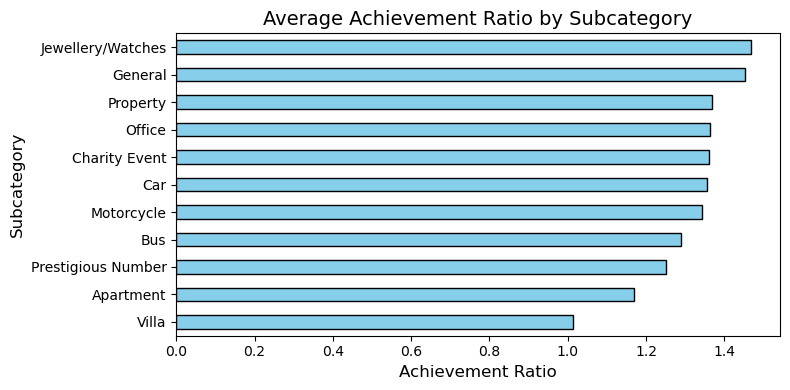

Average Bids per Auction per Subcategory:
subcategory
Charity Event         405.2
Office                 53.8
Bus                    49.3
Villa                  48.0
Motorcycle             42.3
General                42.0
Car                    41.6
Prestigious Number     40.9
Jewellery/Watches      40.3
Apartment              39.0
Property               38.9
Name: bids_count, dtype: float64
--------------------------------------------------


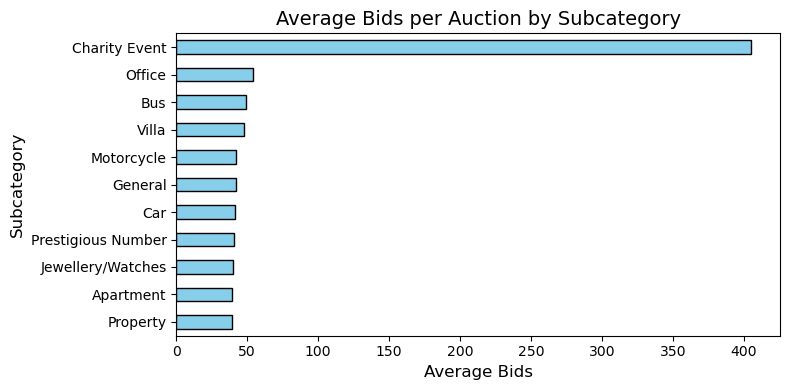

In [19]:
# --- Step 6.4b – Subcategory Performance Insights ---
# 1) Average achievement ratio per subcategory
subcat_avg_ratio = df.groupby('subcategory')['achievement_ratio'].mean().sort_values(ascending=False)
print("Average Achievement Ratio per Subcategory:")
print(subcat_avg_ratio.round(2))
print("-" * 50)
plot_barh(subcat_avg_ratio, "Average Achievement Ratio by Subcategory", "Achievement Ratio", "Subcategory")

# 2) Average bids per auction per subcategory
subcat_avg_bids = df.groupby('subcategory')['bids_count'].mean().sort_values(ascending=False)
print("Average Bids per Auction per Subcategory:")
print(subcat_avg_bids.round(1))
print("-" * 50)
plot_barh(subcat_avg_bids, "Average Bids per Auction by Subcategory", "Average Bids", "Subcategory")

### Interpretation  
**Charity Event** auctions record extremely high engagement (~405 bids per auction),  
while **Jewellery/Watches** and **General** subcategories achieve the strongest price efficiency (≈1.45).  
Luxury-oriented items show strong demand, while property and vehicle subcategories maintain moderate performance.

### Step 6.4c – Listing Type Performance Insights  

Compare **pricing efficiency** and **bidding intensity** across **listing types**  
(e.g., Auction, BuyNow, Charity Auction) to assess format-driven performance.

Average Achievement Ratio per Listing Type:
listing_type
BuyNow             1.40
Auction            1.38
Charity Auction    1.36
Name: achievement_ratio, dtype: float64
--------------------------------------------------


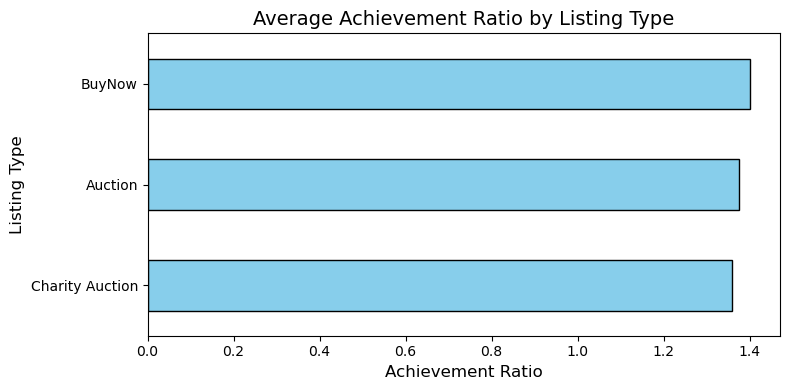

Average Bids per Auction per Listing Type:
listing_type
Charity Auction    405.2
Auction             41.7
BuyNow              41.5
Name: bids_count, dtype: float64
--------------------------------------------------


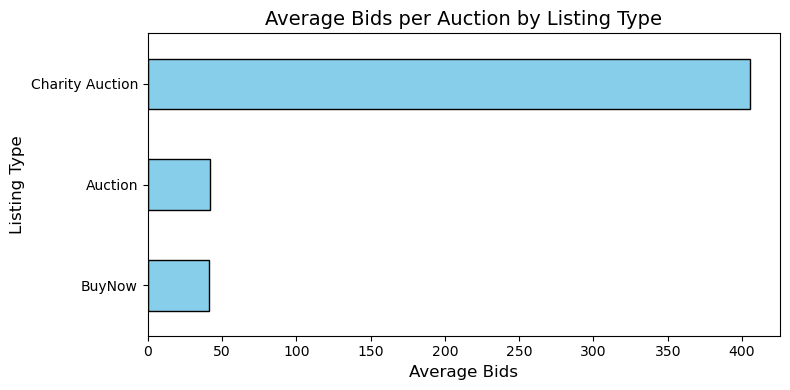

In [20]:
# --- Step 6.4c – Listing Type Performance Insights ---
# 1) Average achievement ratio per listing type
lt_avg_ratio = df.groupby('listing_type')['achievement_ratio'].mean().sort_values(ascending=False)
print("Average Achievement Ratio per Listing Type:")
print(lt_avg_ratio.round(2))
print("-" * 50)
plot_barh(lt_avg_ratio, "Average Achievement Ratio by Listing Type", "Achievement Ratio", "Listing Type")

# 2) Average bids per auction per listing type
lt_avg_bids = df.groupby('listing_type')['bids_count'].mean().sort_values(ascending=False)
print("Average Bids per Auction per Listing Type:")
print(lt_avg_bids.round(1))
print("-" * 50)
plot_barh(lt_avg_bids, "Average Bids per Auction by Listing Type", "Average Bids", "Listing Type")

### Interpretation  
**Charity Auctions** dominate participation (≈400 bids per auction) and total value,  
confirming high emotional and social engagement.  
**BuyNow** listings achieve the highest pricing ratio (≈1.4),  
indicating strong price realization despite fewer bids.

### Summary of Category-Level Insights  

- **Volume Leaders:** Vehicles and General Items drive the majority of auctions.  
- **Value Leaders:** Charity and Plates categories lead in total auction value (AED).  
- **Engagement:** Charity Events achieve the highest average bidding activity (≈400 bids per auction).  
- **Efficiency:** Jewellery & Watches and General Items show the best price-to-target ratios.  

Together, these results highlight a balanced marketplace —  
socially driven auctions achieve the widest engagement, while collectible segments excel in pricing efficiency.

## Step 7 – Time and Trend Analysis  

This step examines **temporal patterns in auction activity and performance**,  
highlighting how participation levels, pricing behavior, and efficiency metrics  
vary across different time periods (months and quarters).  

**Focus Variables**  
- `month`, `auction_quarter`, `duration_days`  
- `bids_count`, `final_price`, `achievement_ratio`  

**Objectives**  
- Analyze auction distribution and trends over time.  
- Identify seasonal or quarterly peaks in engagement and value.  
- Evaluate consistency in pricing performance across time periods.

## Step 7.1 – Monthly Auction Activity and Performance Trends

Number of Auctions per Month:
month
1.0        4
2.0        4
3.0        6
4.0        5
5.0        2
6.0        4
7.0        5
8.0        4
9.0     1036
10.0    1297
11.0     217
12.0       8
Name: count, dtype: int64
--------------------------------------------------


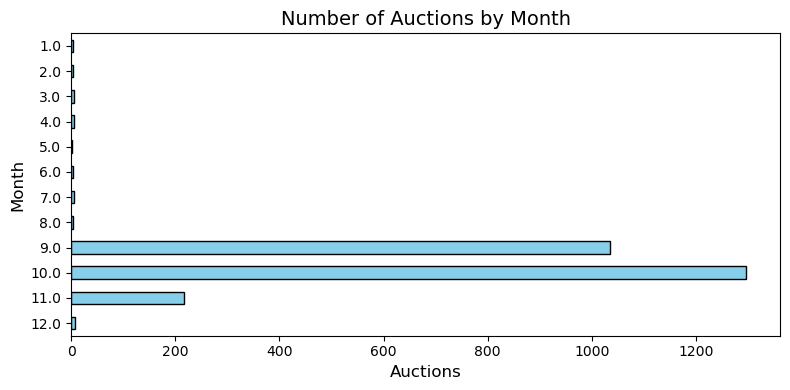

Average Final Price (AED) per Month:
month
1.0     16,639,200
2.0      2,978,630
3.0     34,641,384
4.0     32,894,582
5.0     18,272,700
6.0     42,143,200
7.0     10,627,171
8.0      5,924,272
9.0        666,423
10.0       549,207
11.0     1,020,923
12.0     4,747,308
Name: final_price, dtype: object
--------------------------------------------------


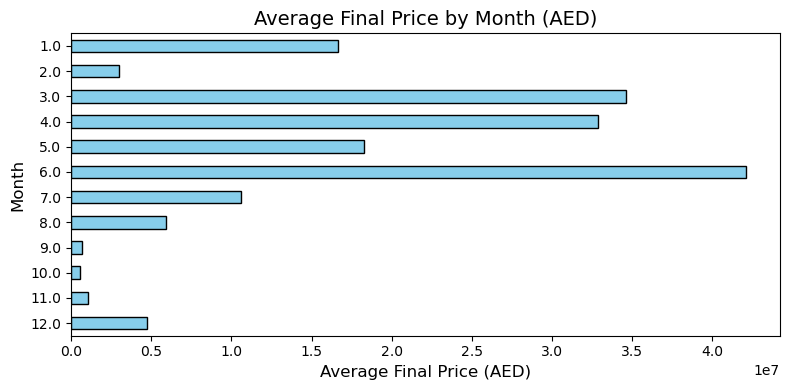

Average Achievement Ratio per Month:
month
1.0     1.32
2.0     1.39
3.0     1.34
4.0     1.37
5.0     1.36
6.0     1.35
7.0     1.36
8.0     1.35
9.0     1.38
10.0    1.38
11.0    1.39
12.0    1.36
Name: achievement_ratio, dtype: float64
--------------------------------------------------


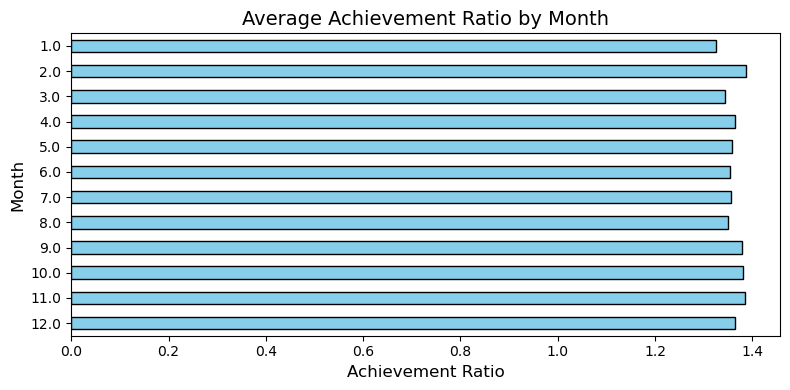

In [21]:
# --- Step 7.1 – Monthly Performance Overview ---
# Purpose: Analyze auction activity and pricing trends across months.

# 1️ Number of auctions per month
month_counts = df['month'].value_counts().sort_index()
print("Number of Auctions per Month:")
print(month_counts)
print("-" * 50)
plot_barh(month_counts, "Number of Auctions by Month", "Auctions", "Month")

# 2️ Average final price per month (AED)
avg_final_price_month = df.groupby('month')['final_price'].mean().sort_index()
print("Average Final Price (AED) per Month:")
print(avg_final_price_month.apply(lambda x: f"{x:,.0f}"))
print("-" * 50)
plot_barh(avg_final_price_month, "Average Final Price by Month (AED)", "Average Final Price (AED)", "Month")

# 3️ Average achievement ratio per month
avg_ratio_month = df.groupby('month')['achievement_ratio'].mean().sort_index()
print("Average Achievement Ratio per Month:")
print(avg_ratio_month.round(2))
print("-" * 50)
plot_barh(avg_ratio_month, "Average Achievement Ratio by Month", "Achievement Ratio", "Month")

### Interpretation

Auction activity peaks in **September** and **October**,  
indicating strong seasonal concentration.  
Mid-year months (**March–June**) achieve the highest **average final prices**,  
while the **achievement ratio** stays steady (~1.36–1.39),  
showing consistent efficiency across the year.

## Step 7.2 – Quarterly Trends Analysis  

This step examines **auction activity and performance by quarter**,  
to identify broader seasonal trends in participation and pricing outcomes.  

**Focus Variables**  
- `auction_quarter`  
- `final_price`, `achievement_ratio`, `bids_count`

Number of Auctions per Quarter:
auction_quarter
1.0      14
2.0      11
3.0    1045
4.0    1522
Name: count, dtype: int64
--------------------------------------------------


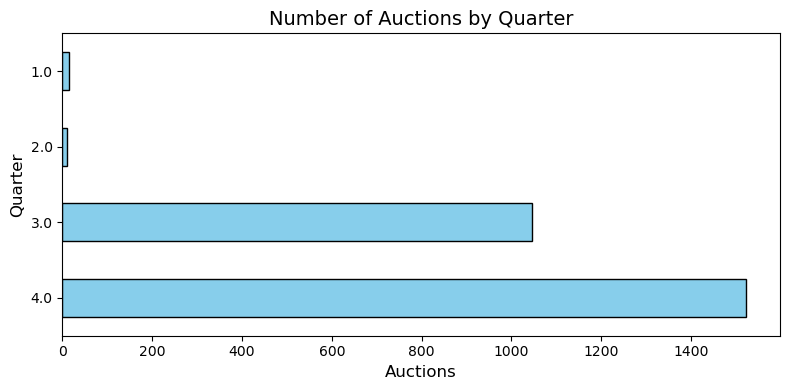

Average Final Price (AED) per Quarter:
auction_quarter
1.0    20,451,402
2.0    33,599,192
3.0       734,208
4.0       638,528
Name: final_price, dtype: object
--------------------------------------------------


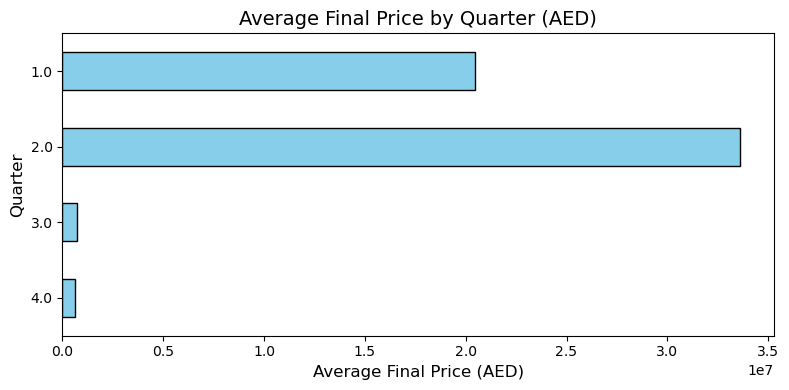

Average Achievement Ratio per Quarter:
auction_quarter
1.0    1.35
2.0    1.36
3.0    1.38
4.0    1.38
Name: achievement_ratio, dtype: float64
--------------------------------------------------


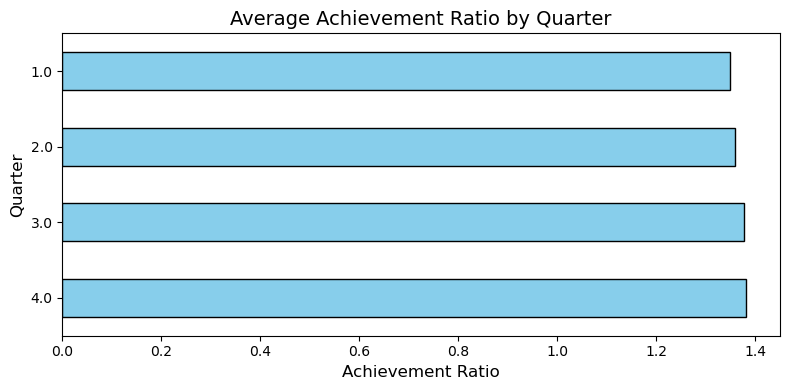

In [22]:
# --- Step 7.2 – Quarterly Trends Analysis ---
# Purpose: Evaluate auction trends by quarter to identify seasonal or market effects.

# 1️ Auction count by quarter
quarter_counts = df['auction_quarter'].value_counts().sort_index()
print("Number of Auctions per Quarter:")
print(quarter_counts)
print("-" * 50)
plot_barh(quarter_counts, "Number of Auctions by Quarter", "Auctions", "Quarter")

# 2️ Average final price by quarter
quarter_price = df.groupby('auction_quarter')['final_price'].mean().sort_index()
print("Average Final Price (AED) per Quarter:")
print(quarter_price.apply(lambda x: f"{x:,.0f}"))
print("-" * 50)
plot_barh(quarter_price, "Average Final Price by Quarter (AED)", "Average Final Price (AED)", "Quarter")

# 3️ Average achievement ratio by quarter
quarter_ratio = df.groupby('auction_quarter')['achievement_ratio'].mean().sort_index()
print("Average Achievement Ratio per Quarter:")
print(quarter_ratio.round(2))
print("-" * 50)
plot_barh(quarter_ratio, "Average Achievement Ratio by Quarter", "Achievement Ratio", "Quarter")

### Interpretation

Auction activity peaks sharply in **Q3–Q4**, reflecting higher listing volumes toward year-end.  
However, **average final prices** are highest in **Q1–Q2**, suggesting stronger value performance in early months.  
The **achievement ratio** remains consistently around **1.35–1.38**,  
indicating stable pricing efficiency across quarters despite seasonal variation in activity.

## Step 7.3 – Time-of-Day Patterns  

This step focuses on **auction start times** to explore when auctions are most active  
and whether specific hours correspond to higher engagement or better pricing outcomes.  

**Focus Variables**  
- `hour_of_day`  
- `bids_count`, `final_price`, `achievement_ratio`  

Number of Auctions by Hour of Day:
hour_of_day
0.0     123
1.0      95
2.0     104
3.0     128
4.0      98
5.0     100
6.0     108
7.0     106
8.0     104
9.0      89
10.0     94
11.0    118
12.0     89
13.0    109
14.0    112
15.0    106
16.0    113
17.0    118
18.0    116
19.0    103
20.0    110
21.0    130
22.0    109
23.0    110
Name: count, dtype: int64
--------------------------------------------------


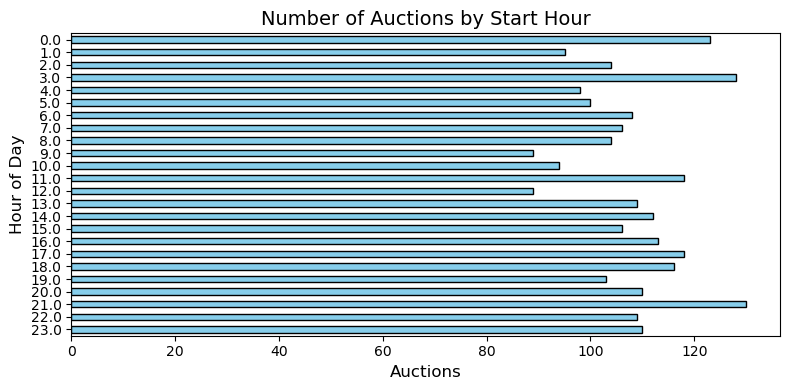

Average Final Price (AED) by Start Hour:
hour_of_day
0.0       633,284
1.0       334,256
2.0     2,723,789
3.0       677,931
4.0     1,669,398
5.0     2,696,447
6.0       660,045
7.0     1,383,525
8.0     1,480,109
9.0       806,217
10.0      443,212
11.0      426,544
12.0      498,970
13.0      552,778
14.0    2,171,978
15.0      490,023
16.0      712,492
17.0      540,435
18.0      673,082
19.0      687,326
20.0      444,819
21.0      670,942
22.0      395,830
23.0      673,814
Name: final_price, dtype: object
--------------------------------------------------


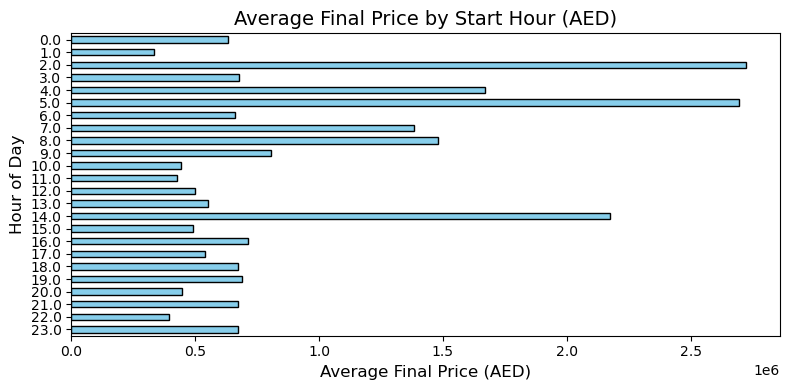

In [23]:
# --- Step 7.3 – Time-of-Day Patterns ---
# Purpose: Evaluate how auction start hour relates to participation and pricing.

# 1️ Number of auctions by start hour
hour_counts = df['hour_of_day'].value_counts().sort_index()
print("Number of Auctions by Hour of Day:")
print(hour_counts)
print("-" * 50)
plot_barh(hour_counts, "Number of Auctions by Start Hour", "Auctions", "Hour of Day")

# 2️ Average final price by start hour
hour_price = df.groupby('hour_of_day')['final_price'].mean().sort_index()
print("Average Final Price (AED) by Start Hour:")
print(hour_price.apply(lambda x: f"{x:,.0f}"))
print("-" * 50)
plot_barh(hour_price, "Average Final Price by Start Hour (AED)", "Average Final Price (AED)", "Hour of Day")

### Interpretation
Most auctions start between **midnight and early morning (0–4h)**,  
with another activity peak around **evening hours (18–22h)**.  
However, **highest average final prices** appear concentrated in a few specific hours (e.g., 2–5h and 14h),  
suggesting that limited but high-value auctions occur outside typical peak times.  
Overall, auction timing shows moderate influence — performance varies more by auction type than by hour.

## – Summary of Temporal Insights  

Overall, **auction activity** peaks during **Q3–Q4** and around **midnight to early morning** hours.  
While **volume** increases sharply late in the year, **average prices** stay higher in earlier quarters.  
This suggests that **auction value and engagement intensity** vary over time,  
but strong timing patterns are limited — implying that auction success depends more on **item type and demand** than seasonality.

## Step 8 – Overall Findings & Strategic Insights  

**Purpose:** Summarize the main analytical findings and highlight actionable insights.  
All monetary values are expressed in **UAE Dirhams (AED)**.

---

### 8.1 Financial Performance  
- Most auctions cluster at **lower price ranges**, showing a **right-skewed distribution**.  
- **High-value outliers** (mainly *Charity* and *Plates*) dominate total revenue — **over AED 1 billion combined**.  
- The **achievement ratio** averages around **1.3–1.4**, reflecting strong performance relative to targets.

---

### 8.2 Engagement Behavior  
- Average engagement is around **40–45 bids per auction**, showing healthy participation.  
- *Charity auctions* stand out with an exceptional **~400 bids per auction**.  
- **Views**, **bids_count**, and **num_bidders** show **strong positive correlation** with `final_price`.

---

### 8.3 Category-Level Insights  
- *Charity* and *Plates* dominate both in **total value** and **engagement**.  
- *Jewellery & Watches* and *General Items* deliver **the highest pricing efficiency** (`achievement_ratio ≈ 1.45`).  
- *Property* and *Vehicle* auctions remain **stable but less competitive**.

---

### 8.4 Temporal Trends  
- Auction activity **peaks during September–October (Q3–Q4)**.  
- Achievement ratios stay **consistent year-round (≈1.35–1.39)**, indicating **pricing stability**.  
- Higher final prices appear in **early morning (2–5 AM)** and **mid-afternoon (2–3 PM)** slots.

---

### 8.5 Strategic Implications  
- Schedule **high-value auctions** in **Q3–Q4** to leverage seasonal demand.  
- Prioritize **early-morning and afternoon** hours for premium listings.  
- Expand **high-performing segments** (*Charity*, *Plates*) and improve engagement in others.

---

## Final Conclusion  

**Purpose:** Summarize the overall project outcome and analytical impact.  

---

This analytical exploration of **Emirates Auctions 2025** successfully identified the key drivers behind  
auction performance, pricing efficiency, and bidder engagement.  
The dataset exhibited **strong internal consistency**, **minimal missing data**,  
and **stable behavioral patterns** across financial and temporal dimensions.  

---

### Financial Summary  
Auctions displayed a **right-skewed price distribution**, where a few **high-value outliers** —  
mainly in *Charity* and *Plates* categories — dominate total revenue.  
Engagement metrics (`bids_count`, `num_bidders`, `views`) are **strongly correlated** with higher `final_price`,  
confirming that **participation intensity is a direct driver of auction success**.  

---

### Temporal & Behavioral Findings  
The analysis revealed clear timing signals:  
auction activity **peaks during Q3–Q4**, while **morning (2–5 AM)** and **mid-afternoon (2–3 PM)** slots  
tend to achieve **higher final prices**.  
These patterns provide **actionable insights** for optimizing scheduling, pricing, and promotional timing.  

---

### Strategic Insights  
- Prioritize auction scheduling in **Q3–Q4** to leverage seasonal demand.  
- Target **high-engagement hours** (early morning & afternoon) for premium listings.  
- Reinforce **high-performing categories** (*Charity*, *Plates*) with focused marketing.  

---

### Closing Statement  
The **Emirates Auctions dataset** reflects a **mature, data-driven ecosystem**,  
where **competition intensity** and **strategic timing** are central to maximizing returns.  
These insights establish a solid foundation for further **visualization in Power BI or R**,  
and for **predictive modeling** to forecast auction success more precisely.  
